Analysis settings
-----------------
FAST_MODE: False
GA population: 150
GA generations: 300
PSO particles: 150
PSO iterations: 300

Available columns:
 - Sample ID
 - Sludge %
 - Plasticizer %
 - Density
 - σm Flexural (MPa)
 - mean σc Compression (MPa)

Dataset check
-------------
Original rows: 32
Usable rows: 32
Removed rows: 0


,Sample ID,Sludge %,Plasticizer %,Density,σm Flexural (MPa),mean σc Compression (MPa)
0,C1,0.0,0.0,0.002070,15.058,73.351
1,C2,0.0,0.0,0.002122,13.920,77.499
2,C3,0.0,0.0,0.002108,15.412,79.204
3,1,1.0,0.0,0.002097,11.896,70.210
4,2,1.0,0.0,0.002116,13.340,69.879



Input matrix shape: (32, 3)
Flexural target shape: (32,)
Compression target shape: (32,)

Target: σm Flexural
GA LOOCV: 32/32
GA {'R²': 0.6093809245693834, 'RMSE (MPa)': np.float64(2.075507191350642), 'MAE (MPa)': 1.3884552644257364, 'MAPE (%)': np.float64(13.122572019192638)}
PSO LOOCV: 32/32
PSO {'R²': 0.6093809147512887, 'RMSE (MPa)': np.float64(2.075507217434271), 'MAE (MPa)': 1.3884552707107796, 'MAPE (%)': np.float64(13.122572068287147)}

Target: σc Compression
GA LOOCV: 32/32
GA {'R²': 0.8755430222007199, 'RMSE (MPa)': np.float64(5.292973561227886), 'MAE (MPa)': 3.9673176351195867, 'MAPE (%)': np.float64(6.688197702598497)}
PSO LOOCV: 32/32
PSO {'R²': 0.8755430218559739, 'RMSE (MPa)': np.float64(5.292973568558657), 'MAE (MPa)': 3.9673176393657403, 'MAPE (%)': np.float64(6.688197731501116)}

LOOCV performance results
-------------------------


,Output,Algorithm,R²,RMSE (MPa),MAE (MPa),MAPE (%)
0,σm Flexural,GA,0.6094,2.0755,1.3885,13.1226
1,σm Flexural,PSO,0.6094,2.0755,1.3885,13.1226
2,σc Compression,GA,0.8755,5.2930,3.9673,6.6882
3,σc Compression,PSO,0.8755,5.2930,3.9673,6.6882



Final full-data fit: σm Flexural

Final full-data fit: σc Compression

--------------------------------------------------------------------------------
GA equation for σm Flexural
--------------------------------------------------------------------------------
σm = -436.31018 + 4.9835022(S) - 120.49139(P) + 441569.12(D) - 0.057749139(S²) - 28.236131(P²) - 1.081045e+08(D²) + 4.5006156(SP) - 2237.8085(SD) + 34504.139(PD)

--------------------------------------------------------------------------------
PSO equation for σm Flexural
--------------------------------------------------------------------------------
σm = -436.31018 + 4.9835022(S) - 120.49139(P) + 441569.12(D) - 0.057749139(S²) - 28.236131(P²) - 1.081045e+08(D²) + 4.5006156(SP) - 2237.8085(SD) + 34504.139(PD)

--------------------------------------------------------------------------------
GA equation for σc Compression
--------------------------------------------------------------------------------
σc = -2154.4136 + 24.05795(S

,Output,Algorithm,Intercept,S,P,D,S²,P²,D²,SP,SD,PD
0,σm Flexural,GA,-436.310182,4.983502,-120.491387,4.415691e+05,-0.057749,-28.236131,-1.081045e+08,4.500616,-2237.808483,34504.138803
1,σm Flexural,PSO,-436.310181,4.983502,-120.491387,4.415691e+05,-0.057749,-28.236131,-1.081045e+08,4.500616,-2237.808483,34504.138804
2,σc Compression,GA,-2154.413638,24.057950,-221.762557,2.043386e+06,-0.222817,-76.658835,-4.673659e+08,12.929674,-10386.676351,37613.923527
3,σc Compression,PSO,-2154.413638,24.057950,-221.762558,2.043386e+06,-0.222817,-76.658835,-4.673659e+08,12.929674,-10386.676351,37613.923527


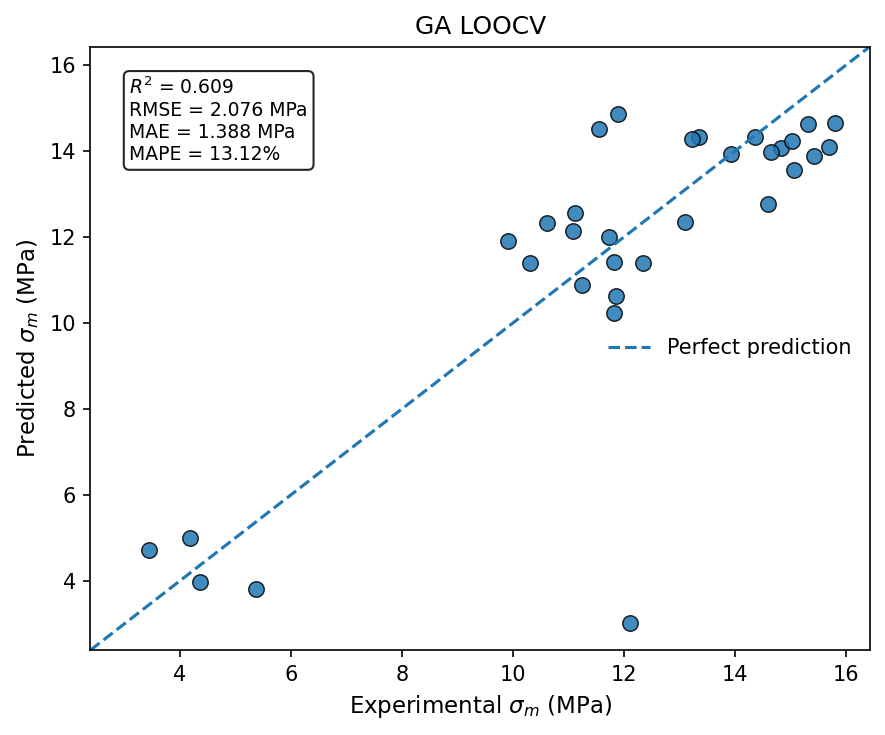

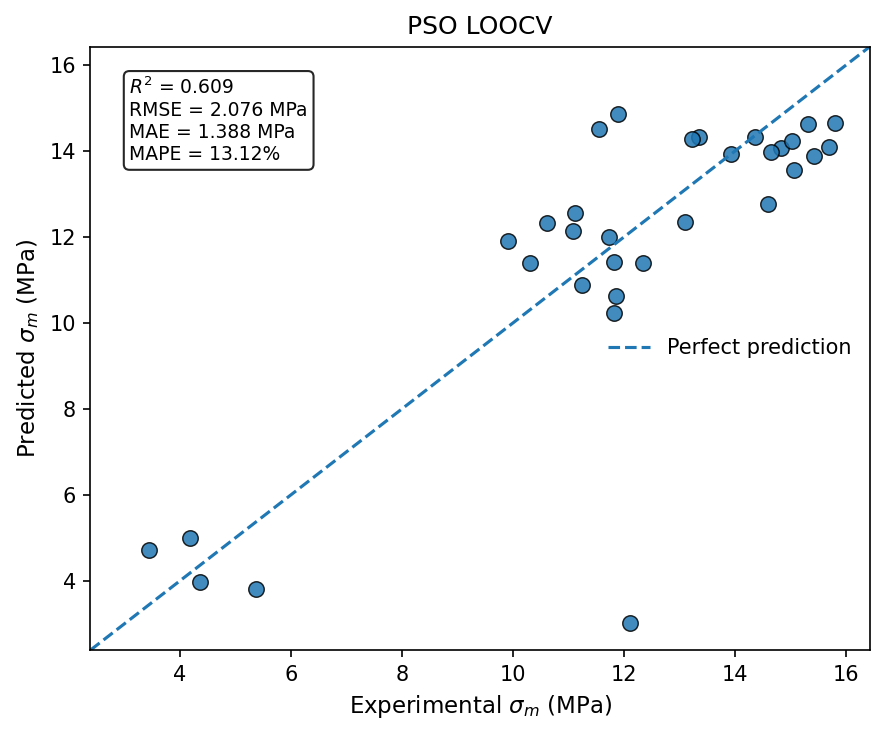

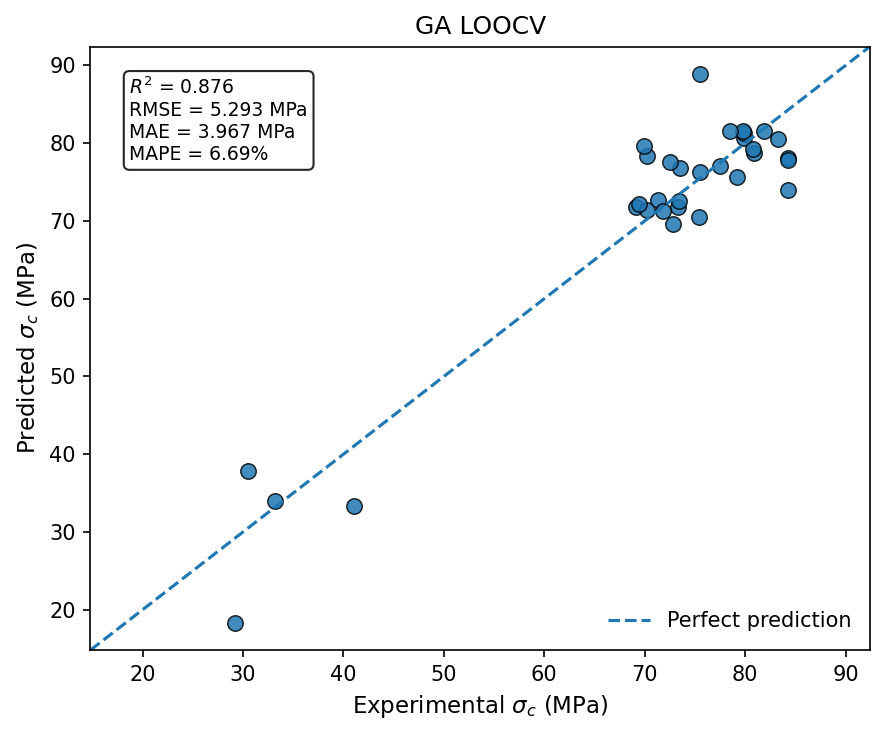

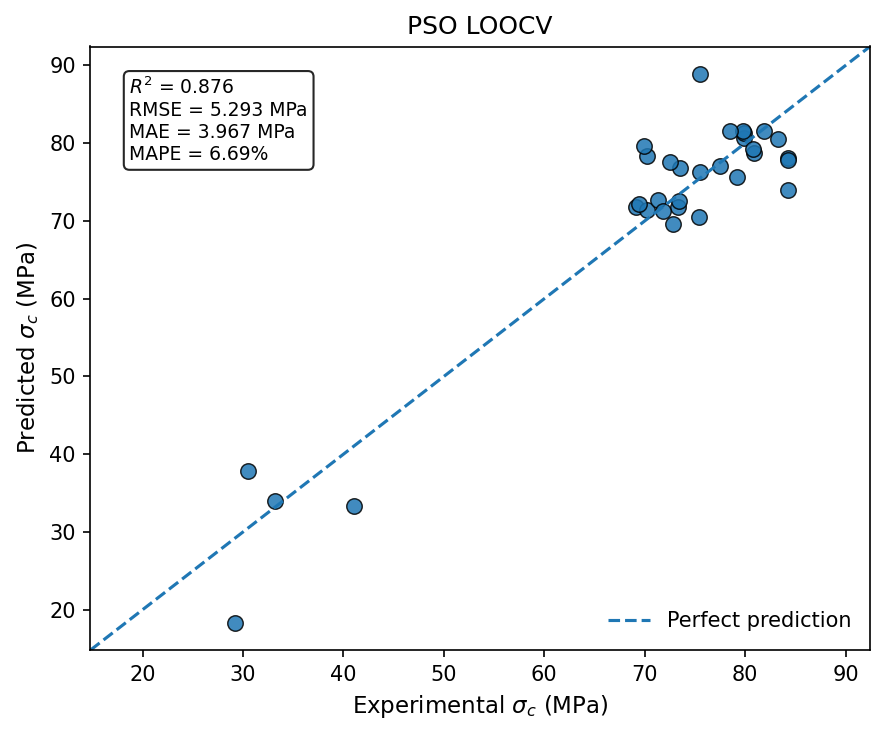

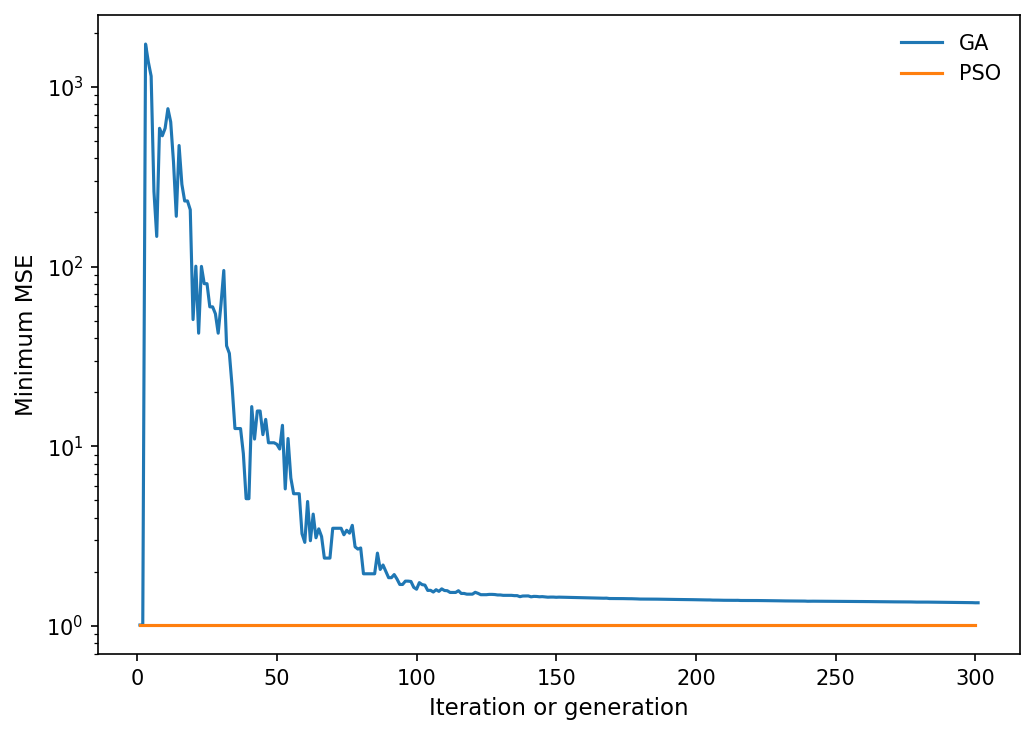

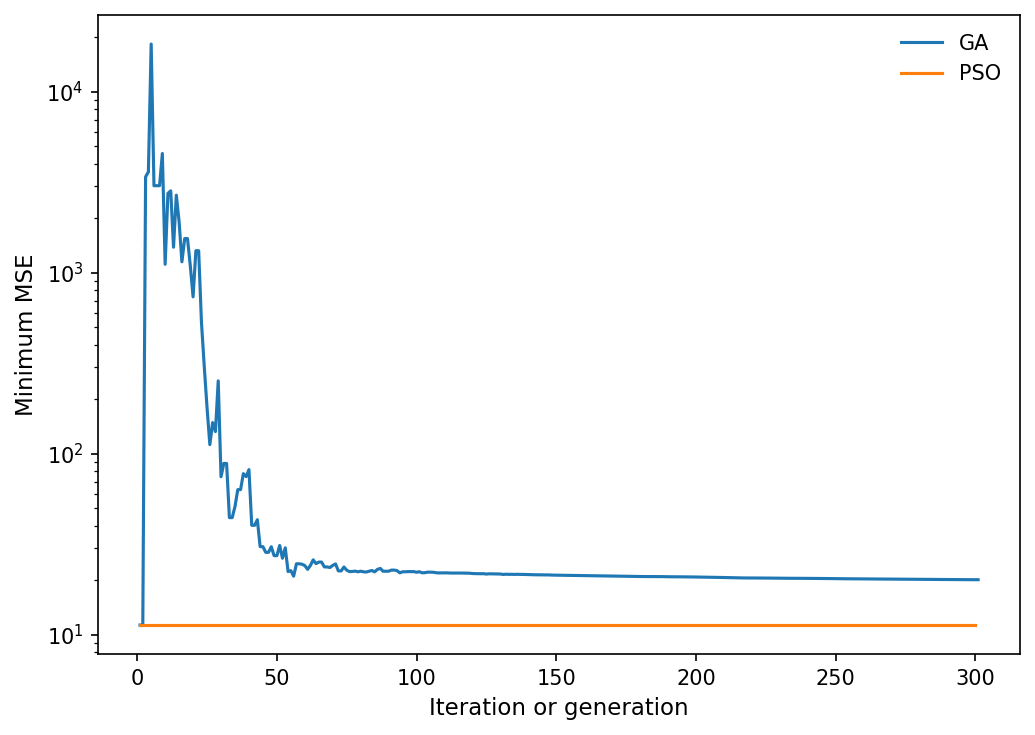


ANALYSIS COMPLETED

Results saved to:
/content/GA_PSO_Final_Results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ================================================================
# GA AND PSO OPTIMIZATION OF SECOND-ORDER EMPIRICAL EQUATIONS
# WITH LEAVE-ONE-OUT CROSS-VALIDATION
#
# Inputs:
# S = Sludge content (%)
# P = Plasticizer dosage (%)
# D = Density
#
# Outputs:
# σm = Flexural strength (MPa)
# σc = Compressive strength (MPa)
#
# Final equations:
# y = β0 + β1S + β2P + β3D
#     + β4S² + β5P² + β6D²
#     + β7SP + β8SD + β9PD
# ================================================================

# Install required packages
!pip install -q deap pyswarms openpyxl

# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyswarms as ps

from deap import base, creator, tools, algorithms
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

warnings.filterwarnings("ignore")

# ================================================================
# 2. GENERAL SETTINGS
# ================================================================

FILE_PATH = "/content/Final.xlsx"
OUTPUT_FILE = "/content/GA_PSO_Final_Results.xlsx"

GLOBAL_SEED = 42

np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)

# For a quick initial test, set FAST_MODE = True.
# For the final analysis, keep it False.
FAST_MODE = False

if FAST_MODE:
    GA_POPULATION = 50
    GA_GENERATIONS = 80

    PSO_PARTICLES = 50
    PSO_ITERATIONS = 80

else:
    GA_POPULATION = 150
    GA_GENERATIONS = 300

    PSO_PARTICLES = 150
    PSO_ITERATIONS = 300

GA_CROSSOVER_PROBABILITY = 0.80
GA_MUTATION_PROBABILITY = 0.20

PSO_C1 = 1.5
PSO_C2 = 1.5
PSO_INERTIA = 0.7

BOUND_EXPANSION = 5.0

print("Analysis settings")
print("-----------------")
print("FAST_MODE:", FAST_MODE)
print("GA population:", GA_POPULATION)
print("GA generations:", GA_GENERATIONS)
print("PSO particles:", PSO_PARTICLES)
print("PSO iterations:", PSO_ITERATIONS)

# ================================================================
# 3. LOAD AND CHECK THE DATASET
# ================================================================

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(
        f"File not found: {FILE_PATH}\n"
        "Upload Final.xlsx to the Colab Files section."
    )

df = pd.read_excel(FILE_PATH)

# Remove accidental spaces from column names
df.columns = [
    str(column).strip()
    for column in df.columns
]

print("\nAvailable columns:")
for column in df.columns:
    print(" -", column)

sample_column = "Sample ID"

input_columns = [
    "Sludge %",
    "Plasticizer %",
    "Density"
]

flexural_column = "σm Flexural (MPa)"
compression_column = "mean σc Compression (MPa)"

required_columns = (
    [sample_column]
    + input_columns
    + [flexural_column, compression_column]
)

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        "These required columns were not found:\n"
        + "\n".join(missing_columns)
    )

data = df[required_columns].copy()

numerical_columns = (
    input_columns
    + [flexural_column, compression_column]
)

for column in numerical_columns:
    data[column] = pd.to_numeric(
        data[column],
        errors="coerce"
    )

before_cleaning = len(data)

data = data.dropna(
    subset=numerical_columns
).reset_index(drop=True)

after_cleaning = len(data)

print("\nDataset check")
print("-------------")
print("Original rows:", before_cleaning)
print("Usable rows:", after_cleaning)
print("Removed rows:", before_cleaning - after_cleaning)

display(data.head())

# ================================================================
# 4. DEFINE INPUTS AND OUTPUTS
# ================================================================

X = data[input_columns].to_numpy(dtype=float)

y_flexural = data[
    flexural_column
].to_numpy(dtype=float)

y_compression = data[
    compression_column
].to_numpy(dtype=float)

sample_ids = data[
    sample_column
].astype(str).to_numpy()

print("\nInput matrix shape:", X.shape)
print("Flexural target shape:", y_flexural.shape)
print("Compression target shape:", y_compression.shape)

# ================================================================
# 5. CREATE THE SECOND-ORDER POLYNOMIAL MATRIX
#
# Terms:
# 1, S, P, D, S², P², D², SP, SD, PD
# ================================================================

TERM_NAMES = [
    "Intercept",
    "S",
    "P",
    "D",
    "S²",
    "P²",
    "D²",
    "SP",
    "SD",
    "PD"
]


def create_polynomial_matrix(X_values):
    """
    Create the second-order polynomial design matrix.

    X columns:
    0 = Sludge content
    1 = Plasticizer dosage
    2 = Density
    """

    S = X_values[:, 0]
    P = X_values[:, 1]
    D = X_values[:, 2]

    return np.column_stack([
        np.ones(len(X_values)),
        S,
        P,
        D,
        S**2,
        P**2,
        D**2,
        S * P,
        S * D,
        P * D
    ])


# ================================================================
# 6. STANDARDIZE POLYNOMIAL TERMS
#
# Scaling is performed inside each LOOCV fold using only the
# training samples to prevent information leakage.
# ================================================================

def fit_design_scaler(Phi):
    """
    Calculate means and standard deviations of polynomial terms.
    The intercept is not standardized.
    """

    means = np.mean(
        Phi[:, 1:],
        axis=0
    )

    standard_deviations = np.std(
        Phi[:, 1:],
        axis=0,
        ddof=0
    )

    standard_deviations[
        standard_deviations == 0
    ] = 1.0

    return means, standard_deviations


def transform_design_matrix(
    Phi,
    means,
    standard_deviations
):
    """
    Standardize the polynomial terms and retain the intercept.
    """

    standardized_terms = (
        Phi[:, 1:] - means
    ) / standard_deviations

    return np.column_stack([
        np.ones(len(Phi)),
        standardized_terms
    ])


def convert_scaled_to_raw_coefficients(
    scaled_coefficients,
    means,
    standard_deviations
):
    """
    Convert coefficients from standardized polynomial terms
    back to the original input-variable scale.
    """

    scaled_coefficients = np.asarray(
        scaled_coefficients,
        dtype=float
    )

    raw_coefficients = np.zeros_like(
        scaled_coefficients
    )

    raw_coefficients[1:] = (
        scaled_coefficients[1:]
        / standard_deviations
    )

    raw_coefficients[0] = (
        scaled_coefficients[0]
        - np.sum(
            scaled_coefficients[1:]
            * means
            / standard_deviations
        )
    )

    return raw_coefficients


# ================================================================
# 7. PREDICTION AND OBJECTIVE FUNCTIONS
# ================================================================

def predict_response(
    coefficients,
    design_matrix
):
    """
    Predict the target response.
    """

    coefficients = np.asarray(
        coefficients,
        dtype=float
    )

    return design_matrix @ coefficients


def calculate_mse(
    coefficients,
    design_matrix,
    target
):
    """
    Objective function minimized by GA and PSO.
    """

    predictions = predict_response(
        coefficients,
        design_matrix
    )

    mse = np.mean(
        (target - predictions)**2
    )

    if not np.isfinite(mse):
        return 1e100

    return float(mse)


# ================================================================
# 8. CREATE COEFFICIENT SEARCH BOUNDS
# ================================================================

def create_coefficient_bounds(
    design_matrix,
    target,
    expansion=5.0
):
    """
    Use the least-squares coefficients only to define a reasonable
    search interval for GA and PSO.
    """

    least_squares_coefficients = np.linalg.lstsq(
        design_matrix,
        target,
        rcond=None
    )[0]

    coefficient_scale = np.maximum(
        np.abs(least_squares_coefficients),
        1.0
    )

    lower_bounds = (
        least_squares_coefficients
        - expansion * coefficient_scale
    )

    upper_bounds = (
        least_squares_coefficients
        + expansion * coefficient_scale
    )

    return (
        least_squares_coefficients,
        lower_bounds,
        upper_bounds
    )


# ================================================================
# 9. GENETIC ALGORITHM
# ================================================================

if not hasattr(creator, "FitnessMinimumGA"):
    creator.create(
        "FitnessMinimumGA",
        base.Fitness,
        weights=(-1.0,)
    )

if not hasattr(creator, "GAIndividual"):
    creator.create(
        "GAIndividual",
        list,
        fitness=creator.FitnessMinimumGA
    )


def optimize_with_ga(
    design_matrix,
    target,
    seed=42,
    population_size=150,
    generations=300,
    crossover_probability=0.80,
    mutation_probability=0.20,
    expansion=5.0
):
    """
    Optimize polynomial coefficients using GA.
    """

    np.random.seed(seed)
    random.seed(seed)

    (
        initial_coefficients,
        lower_bounds,
        upper_bounds
    ) = create_coefficient_bounds(
        design_matrix,
        target,
        expansion=expansion
    )

    number_of_coefficients = design_matrix.shape[1]

    toolbox = base.Toolbox()

    def create_individual():
        values = []

        for index in range(number_of_coefficients):

            if random.random() < 0.70:
                local_sigma = (
                    0.15
                    * (
                        upper_bounds[index]
                        - lower_bounds[index]
                    )
                )

                value = random.gauss(
                    initial_coefficients[index],
                    local_sigma
                )

            else:
                value = random.uniform(
                    lower_bounds[index],
                    upper_bounds[index]
                )

            value = np.clip(
                value,
                lower_bounds[index],
                upper_bounds[index]
            )

            values.append(float(value))

        return creator.GAIndividual(values)

    def evaluate_individual(individual):

        objective_value = calculate_mse(
            individual,
            design_matrix,
            target
        )

        return (objective_value,)

    def bounded_crossover(
        individual_1,
        individual_2
    ):
        tools.cxBlend(
            individual_1,
            individual_2,
            alpha=0.5
        )

        for index in range(number_of_coefficients):

            individual_1[index] = float(
                np.clip(
                    individual_1[index],
                    lower_bounds[index],
                    upper_bounds[index]
                )
            )

            individual_2[index] = float(
                np.clip(
                    individual_2[index],
                    lower_bounds[index],
                    upper_bounds[index]
                )
            )

        return individual_1, individual_2

    def bounded_mutation(
        individual,
        individual_probability=0.20
    ):

        for index in range(number_of_coefficients):

            if random.random() < individual_probability:

                mutation_sigma = (
                    0.08
                    * (
                        upper_bounds[index]
                        - lower_bounds[index]
                    )
                )

                individual[index] += random.gauss(
                    0,
                    mutation_sigma
                )

                individual[index] = float(
                    np.clip(
                        individual[index],
                        lower_bounds[index],
                        upper_bounds[index]
                    )
                )

        return (individual,)

    toolbox.register(
        "individual",
        create_individual
    )

    toolbox.register(
        "population",
        tools.initRepeat,
        list,
        toolbox.individual
    )

    toolbox.register(
        "evaluate",
        evaluate_individual
    )

    toolbox.register(
        "select",
        tools.selTournament,
        tournsize=3
    )

    toolbox.register(
        "mate",
        bounded_crossover
    )

    toolbox.register(
        "mutate",
        bounded_mutation,
        individual_probability=0.20
    )

    population = toolbox.population(
        n=population_size
    )

    # Include the least-squares solution in the initial population.
    population[0][:] = list(
        initial_coefficients
    )

    hall_of_fame = tools.HallOfFame(1)

    statistics = tools.Statistics(
        lambda individual:
        individual.fitness.values[0]
    )

    statistics.register(
        "minimum",
        np.min
    )

    statistics.register(
        "average",
        np.mean
    )

    population, logbook = algorithms.eaSimple(
        population,
        toolbox,
        cxpb=crossover_probability,
        mutpb=mutation_probability,
        ngen=generations,
        stats=statistics,
        halloffame=hall_of_fame,
        verbose=False
    )

    best_coefficients = np.asarray(
        hall_of_fame[0],
        dtype=float
    )

    convergence_history = np.asarray(
        logbook.select("minimum"),
        dtype=float
    )

    return best_coefficients, convergence_history


# ================================================================
# 10. PARTICLE SWARM OPTIMIZATION
# ================================================================

def optimize_with_pso(
    design_matrix,
    target,
    seed=42,
    number_of_particles=150,
    iterations=300,
    c1=1.5,
    c2=1.5,
    inertia_weight=0.7,
    expansion=5.0
):
    """
    Optimize polynomial coefficients using PSO.
    """

    np.random.seed(seed)
    random.seed(seed)

    (
        initial_coefficients,
        lower_bounds,
        upper_bounds
    ) = create_coefficient_bounds(
        design_matrix,
        target,
        expansion=expansion
    )

    dimensions = design_matrix.shape[1]

    options = {
        "c1": c1,
        "c2": c2,
        "w": inertia_weight
    }

    bounds = (
        lower_bounds,
        upper_bounds
    )

    initialization_scale = (
        0.10
        * (
            upper_bounds
            - lower_bounds
        )
    )

    initial_positions = np.random.normal(
        loc=initial_coefficients,
        scale=initialization_scale,
        size=(
            number_of_particles,
            dimensions
        )
    )

    initial_positions = np.clip(
        initial_positions,
        lower_bounds,
        upper_bounds
    )

    initial_positions[0] = (
        initial_coefficients
    )

    def particle_objective(particles):
        """
        Evaluate MSE for all particles simultaneously.
        """

        predictions = (
            particles
            @ design_matrix.T
        )

        errors = (
            predictions
            - target.reshape(1, -1)
        )

        mse_values = np.mean(
            errors**2,
            axis=1
        )

        mse_values[
            ~np.isfinite(mse_values)
        ] = 1e100

        return mse_values

    optimizer = ps.single.GlobalBestPSO(
        n_particles=number_of_particles,
        dimensions=dimensions,
        options=options,
        bounds=bounds,
        init_pos=initial_positions
    )

    best_cost, best_coefficients = optimizer.optimize(
        particle_objective,
        iters=iterations,
        verbose=False
    )

    convergence_history = np.asarray(
        optimizer.cost_history,
        dtype=float
    )

    return (
        np.asarray(
            best_coefficients,
            dtype=float
        ),
        convergence_history
    )


# ================================================================
# 11. PERFORMANCE METRICS
# ================================================================

def calculate_performance_metrics(
    experimental,
    predicted
):
    """
    Calculate R², RMSE, MAE, and MAPE.
    """

    experimental = np.asarray(
        experimental,
        dtype=float
    )

    predicted = np.asarray(
        predicted,
        dtype=float
    )

    r2 = r2_score(
        experimental,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            experimental,
            predicted
        )
    )

    mae = mean_absolute_error(
        experimental,
        predicted
    )

    nonzero_mask = (
        np.abs(experimental) > 1e-12
    )

    if np.any(nonzero_mask):

        mape = (
            np.mean(
                np.abs(
                    (
                        experimental[nonzero_mask]
                        - predicted[nonzero_mask]
                    )
                    / experimental[nonzero_mask]
                )
            )
            * 100
        )

    else:
        mape = np.nan

    return {
        "R²": r2,
        "RMSE (MPa)": rmse,
        "MAE (MPa)": mae,
        "MAPE (%)": mape
    }


# ================================================================
# 12. LOOCV FUNCTION
# ================================================================

def run_loocv(
    X_values,
    target,
    algorithm_name
):
    """
    Perform leave-one-out cross-validation using either GA or PSO.
    """

    loo = LeaveOneOut()

    predictions = np.zeros(
        len(target),
        dtype=float
    )

    total_folds = len(target)

    for fold_number, (
        training_indices,
        test_indices
    ) in enumerate(
        loo.split(X_values),
        start=1
    ):

        X_train = X_values[
            training_indices
        ]

        X_test = X_values[
            test_indices
        ]

        y_train = target[
            training_indices
        ]

        Phi_train_raw = create_polynomial_matrix(
            X_train
        )

        Phi_test_raw = create_polynomial_matrix(
            X_test
        )

        (
            training_means,
            training_standard_deviations
        ) = fit_design_scaler(
            Phi_train_raw
        )

        Phi_train_scaled = transform_design_matrix(
            Phi_train_raw,
            training_means,
            training_standard_deviations
        )

        Phi_test_scaled = transform_design_matrix(
            Phi_test_raw,
            training_means,
            training_standard_deviations
        )

        fold_seed = (
            GLOBAL_SEED
            + fold_number
        )

        if algorithm_name == "GA":

            coefficients, _ = optimize_with_ga(
                Phi_train_scaled,
                y_train,
                seed=fold_seed,
                population_size=GA_POPULATION,
                generations=GA_GENERATIONS,
                crossover_probability=(
                    GA_CROSSOVER_PROBABILITY
                ),
                mutation_probability=(
                    GA_MUTATION_PROBABILITY
                ),
                expansion=BOUND_EXPANSION
            )

        elif algorithm_name == "PSO":

            coefficients, _ = optimize_with_pso(
                Phi_train_scaled,
                y_train,
                seed=fold_seed,
                number_of_particles=(
                    PSO_PARTICLES
                ),
                iterations=(
                    PSO_ITERATIONS
                ),
                c1=PSO_C1,
                c2=PSO_C2,
                inertia_weight=(
                    PSO_INERTIA
                ),
                expansion=BOUND_EXPANSION
            )

        else:
            raise ValueError(
                "algorithm_name must be 'GA' or 'PSO'."
            )

        predictions[test_indices[0]] = (
            predict_response(
                coefficients,
                Phi_test_scaled
            )[0]
        )

        print(
            f"\r{algorithm_name} LOOCV: "
            f"{fold_number}/{total_folds}",
            end=""
        )

    print()

    return predictions


# ================================================================
# 13. RUN LOOCV FOR BOTH TARGETS
# ================================================================

targets = {
    "σm Flexural": y_flexural,
    "σc Compression": y_compression
}

loocv_results = {}

for target_name, target_values in targets.items():

    print("\n" + "=" * 70)
    print("Target:", target_name)
    print("=" * 70)

    for algorithm_name in [
        "GA",
        "PSO"
    ]:

        predictions = run_loocv(
            X,
            target_values,
            algorithm_name
        )

        metrics = calculate_performance_metrics(
            target_values,
            predictions
        )

        loocv_results[
            (
                target_name,
                algorithm_name
            )
        ] = {
            "experimental": target_values,
            "predicted": predictions,
            "metrics": metrics
        }

        print(
            algorithm_name,
            metrics
        )


# ================================================================
# 14. CREATE LOOCV PERFORMANCE TABLE
# ================================================================

performance_rows = []

for (
    target_name,
    algorithm_name
), result in loocv_results.items():

    row = {
        "Output": target_name,
        "Algorithm": algorithm_name
    }

    row.update(
        result["metrics"]
    )

    performance_rows.append(row)

performance_table = pd.DataFrame(
    performance_rows
)

print("\nLOOCV performance results")
print("-------------------------")

display(
    performance_table.round(4)
)


# ================================================================
# 15. FIT FINAL MODELS USING THE COMPLETE DATASET
#
# LOOCV is used for performance evaluation.
# Full-data fitting is used to obtain the final equation coefficients.
# ================================================================

Phi_full_raw = create_polynomial_matrix(
    X
)

(
    full_means,
    full_standard_deviations
) = fit_design_scaler(
    Phi_full_raw
)

Phi_full_scaled = transform_design_matrix(
    Phi_full_raw,
    full_means,
    full_standard_deviations
)

final_models = {}

for target_name, target_values in targets.items():

    print("\n" + "=" * 70)
    print("Final full-data fit:", target_name)
    print("=" * 70)

    ga_scaled_coefficients, ga_history = optimize_with_ga(
        Phi_full_scaled,
        target_values,
        seed=GLOBAL_SEED,
        population_size=GA_POPULATION,
        generations=GA_GENERATIONS,
        crossover_probability=(
            GA_CROSSOVER_PROBABILITY
        ),
        mutation_probability=(
            GA_MUTATION_PROBABILITY
        ),
        expansion=BOUND_EXPANSION
    )

    ga_raw_coefficients = convert_scaled_to_raw_coefficients(
        ga_scaled_coefficients,
        full_means,
        full_standard_deviations
    )

    pso_scaled_coefficients, pso_history = optimize_with_pso(
        Phi_full_scaled,
        target_values,
        seed=GLOBAL_SEED,
        number_of_particles=PSO_PARTICLES,
        iterations=PSO_ITERATIONS,
        c1=PSO_C1,
        c2=PSO_C2,
        inertia_weight=PSO_INERTIA,
        expansion=BOUND_EXPANSION
    )

    pso_raw_coefficients = convert_scaled_to_raw_coefficients(
        pso_scaled_coefficients,
        full_means,
        full_standard_deviations
    )

    final_models[
        (target_name, "GA")
    ] = {
        "scaled_coefficients": ga_scaled_coefficients,
        "raw_coefficients": ga_raw_coefficients,
        "history": ga_history
    }

    final_models[
        (target_name, "PSO")
    ] = {
        "scaled_coefficients": pso_scaled_coefficients,
        "raw_coefficients": pso_raw_coefficients,
        "history": pso_history
    }


# ================================================================
# 16. FORMAT AND PRINT FINAL EQUATIONS
# ================================================================

def format_equation(
    output_symbol,
    coefficients,
    significant_digits=8
):
    """
    Create a readable second-order equation.
    """

    coefficients = np.asarray(
        coefficients,
        dtype=float
    )

    equation = (
        f"{output_symbol} = "
        f"{coefficients[0]:.{significant_digits}g}"
    )

    for coefficient, term_name in zip(
        coefficients[1:],
        TERM_NAMES[1:]
    ):

        sign = "+" if coefficient >= 0 else "-"

        equation += (
            f" {sign} "
            f"{abs(coefficient):.{significant_digits}g}"
            f"({term_name})"
        )

    return equation


equation_rows = []

for (
    target_name,
    algorithm_name
), model in final_models.items():

    if target_name == "σm Flexural":
        output_symbol = "σm"
    else:
        output_symbol = "σc"

    equation = format_equation(
        output_symbol,
        model["raw_coefficients"]
    )

    print("\n" + "-" * 80)
    print(
        f"{algorithm_name} equation for "
        f"{target_name}"
    )
    print("-" * 80)
    print(equation)

    equation_rows.append({
        "Output": target_name,
        "Algorithm": algorithm_name,
        "Final equation": equation
    })

equation_table = pd.DataFrame(
    equation_rows
)


# ================================================================
# 17. CREATE COEFFICIENT TABLE
# ================================================================

coefficient_rows = []

for (
    target_name,
    algorithm_name
), model in final_models.items():

    row = {
        "Output": target_name,
        "Algorithm": algorithm_name
    }

    for term_name, coefficient in zip(
        TERM_NAMES,
        model["raw_coefficients"]
    ):
        row[term_name] = coefficient

    coefficient_rows.append(row)

coefficient_table = pd.DataFrame(
    coefficient_rows
)

print("\nFinal coefficients")
print("------------------")

display(coefficient_table)


# ================================================================
# 18. CREATE LOOCV PREDICTION TABLE
# ================================================================

prediction_table = data.copy()

prediction_table[
    "GA σm predicted"
] = loocv_results[
    ("σm Flexural", "GA")
]["predicted"]

prediction_table[
    "PSO σm predicted"
] = loocv_results[
    ("σm Flexural", "PSO")
]["predicted"]

prediction_table[
    "GA σc predicted"
] = loocv_results[
    ("σc Compression", "GA")
]["predicted"]

prediction_table[
    "PSO σc predicted"
] = loocv_results[
    ("σc Compression", "PSO")
]["predicted"]


# ================================================================
# 19. CREATE JOURNAL-STYLE PARITY PLOTS
# ================================================================

def create_parity_plot(
    experimental,
    predicted,
    target_label,
    algorithm_name,
    filename
):
    """
    Create a parity plot using LOOCV predictions.
    """

    experimental = np.asarray(
        experimental,
        dtype=float
    )

    predicted = np.asarray(
        predicted,
        dtype=float
    )

    metrics = calculate_performance_metrics(
        experimental,
        predicted
    )

    minimum_value = min(
        np.min(experimental),
        np.min(predicted)
    )

    maximum_value = max(
        np.max(experimental),
        np.max(predicted)
    )

    data_range = maximum_value - minimum_value

    if data_range == 0:
        data_range = 1.0

    margin = 0.05 * data_range

    lower_limit = minimum_value - margin
    upper_limit = maximum_value + margin

    plt.figure(
        figsize=(6, 5),
        dpi=150
    )

    plt.scatter(
        experimental,
        predicted,
        s=55,
        edgecolors="black",
        linewidths=0.7,
        alpha=0.85
    )

    plt.plot(
        [lower_limit, upper_limit],
        [lower_limit, upper_limit],
        linestyle="--",
        linewidth=1.5,
        label="Perfect prediction"
    )

    plt.xlabel(
        f"Experimental {target_label} (MPa)",
        fontsize=11
    )

    plt.ylabel(
        f"Predicted {target_label} (MPa)",
        fontsize=11
    )

    plt.title(
        f"{algorithm_name} LOOCV",
        fontsize=12
    )

    metric_text = (
        f"$R^2$ = {metrics['R²']:.3f}\n"
        f"RMSE = {metrics['RMSE (MPa)']:.3f} MPa\n"
        f"MAE = {metrics['MAE (MPa)']:.3f} MPa\n"
        f"MAPE = {metrics['MAPE (%)']:.2f}%"
    )

    plt.text(
        0.05,
        0.95,
        metric_text,
        transform=plt.gca().transAxes,
        verticalalignment="top",
        fontsize=9,
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "alpha": 0.85
        }
    )

    plt.xlim(
        lower_limit,
        upper_limit
    )

    plt.ylim(
        lower_limit,
        upper_limit
    )

    plt.legend(
        frameon=False
    )

    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()


for (
    target_name,
    algorithm_name
), result in loocv_results.items():

    if target_name == "σm Flexural":
        target_label = r"$\sigma_m$"
        short_name = "sigma_m"

    else:
        target_label = r"$\sigma_c$"
        short_name = "sigma_c"

    figure_path = (
        f"/content/"
        f"{algorithm_name}_{short_name}_LOOCV.png"
    )

    create_parity_plot(
        result["experimental"],
        result["predicted"],
        target_label,
        algorithm_name,
        figure_path
    )


# ================================================================
# 20. CREATE CONVERGENCE PLOTS
# ================================================================

for target_name in targets.keys():

    plt.figure(
        figsize=(7, 5),
        dpi=150
    )

    for algorithm_name in [
        "GA",
        "PSO"
    ]:

        history = final_models[
            (target_name, algorithm_name)
        ]["history"]

        plt.plot(
            np.arange(1, len(history) + 1),
            history,
            label=algorithm_name
        )

    plt.xlabel(
        "Iteration or generation",
        fontsize=11
    )

    plt.ylabel(
        "Minimum MSE",
        fontsize=11
    )

    plt.yscale("log")

    plt.legend(
        frameon=False
    )

    plt.tight_layout()

    short_target = (
        "sigma_m"
        if target_name == "σm Flexural"
        else "sigma_c"
    )

    convergence_path = (
        f"/content/"
        f"GA_PSO_convergence_{short_target}.png"
    )

    plt.savefig(
        convergence_path,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()


# ================================================================
# 21. CREATE SETTINGS TABLE
# ================================================================

settings_table = pd.DataFrame({
    "Parameter": [
        "Equation structure",
        "GA population size",
        "GA generations",
        "GA crossover probability",
        "GA mutation probability",
        "PSO number of particles",
        "PSO iterations",
        "PSO cognitive coefficient c1",
        "PSO social coefficient c2",
        "PSO inertia weight",
        "Coefficient-bound expansion",
        "Objective function",
        "Validation method"
    ],
    "Value": [
        "Second-order polynomial",
        GA_POPULATION,
        GA_GENERATIONS,
        GA_CROSSOVER_PROBABILITY,
        GA_MUTATION_PROBABILITY,
        PSO_PARTICLES,
        PSO_ITERATIONS,
        PSO_C1,
        PSO_C2,
        PSO_INERTIA,
        BOUND_EXPANSION,
        "Mean squared error",
        "Leave-one-out cross-validation"
    ]
})


# ================================================================
# 22. SAVE ALL RESULTS TO EXCEL
# ================================================================

with pd.ExcelWriter(
    OUTPUT_FILE,
    engine="openpyxl"
) as writer:

    data.to_excel(
        writer,
        sheet_name="Input data",
        index=False
    )

    performance_table.to_excel(
        writer,
        sheet_name="LOOCV performance",
        index=False
    )

    prediction_table.to_excel(
        writer,
        sheet_name="LOOCV predictions",
        index=False
    )

    coefficient_table.to_excel(
        writer,
        sheet_name="Final coefficients",
        index=False
    )

    equation_table.to_excel(
        writer,
        sheet_name="Final equations",
        index=False
    )

    settings_table.to_excel(
        writer,
        sheet_name="Model settings",
        index=False
    )

print("\n" + "=" * 70)
print("ANALYSIS COMPLETED")
print("=" * 70)

print("\nResults saved to:")
print(OUTPUT_FILE)


# ================================================================
# 23. DOWNLOAD THE EXCEL RESULTS
# ================================================================

from google.colab import files

files.download(
    OUTPUT_FILE
)